# Research Methods Hackathon


In [37]:
# ============================================================
# CELL 1 — PROJECT SETUP
# ============================================================
# Set the main project path and prepare the folders used for data,
# plots, results and notebooks.
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B"
)

DATA_DIR = PROJECT_ROOT / "Datasets"
NOTEBOOK_DIR = PROJECT_ROOT / "Notebook"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"
PLOTS_DIR = OUTPUTS_DIR / "Plots"
RESULTS_DIR = PROJECT_ROOT / "Results csv"

for folder in [DATA_DIR, NOTEBOOK_DIR, OUTPUTS_DIR, PLOTS_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")
print("Dataset folder:", DATA_DIR)
print("Plots folder:", PLOTS_DIR)
print("Results folder:", RESULTS_DIR)

Project folders are ready.
Dataset folder: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Datasets
Plots folder: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots
Results folder: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv


In [38]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================
# Import the libraries needed for data analysis, plots,
# machine learning models, tuning and evaluation.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

pd.set_option("display.max_columns", None)

# Colourful plots, avoiding the default blue style
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42

In [39]:
# ============================================================
# CELL 3 — PLOT SAVING FUNCTION
# ============================================================
# Small helper function to save plots into the Plots folder.
# This keeps all figures ready for the presentation.
# ============================================================

def save_plot(filename):
    path = PLOTS_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {path}")

In [40]:
# ============================================================
# CELL 4 — LOAD TRAINING AND TEST DATA
# ============================================================
# Load both CSV files from the Dataset folder and quickly check
# whether the data has loaded correctly.
# ============================================================

train_path = DATA_DIR / "dataset_B_training.csv"
test_path = DATA_DIR / "dataset_B_testing.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training data shape: (4756, 31)
Testing data shape: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,2.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,3.0,4.0,65+ Years,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,65+ Years,College Graduate,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,55 - 64 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,1.0,35 - 44 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


In [41]:
# ============================================================
# CELL 5 — DATASET OVERVIEW
# ============================================================
# Take a first look at the columns, data types and summary statistics.
# The summary is saved for documentation.
# ============================================================

train_df.info()

overview = train_df.describe(include="all").T
display(overview)

overview.to_csv(RESULTS_DIR / "00_dataset_overview.csv")

print("Dataset overview saved.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
h1n1_concern,4741.0,NaN,NaN,NaN,1.658933,0.892478,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,4734.0,NaN,NaN,NaN,1.30714,0.612811,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4739.0,NaN,NaN,NaN,0.057396,0.232622,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,NaN,NaN,NaN,0.74096,0.438154,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4752.0,NaN,NaN,NaN,0.077652,0.267651,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.842039,0.364743,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.359385,0.479871,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4741.0,NaN,NaN,NaN,0.341278,0.474189,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4736.0,NaN,NaN,NaN,0.704814,0.456174,0.0,0.0,1.0,1.0,1.0


Dataset overview saved.


,Count,Percentage
h1n1_vaccine,,
0,2882,60.6
1,1874,39.4


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\01_target_distribution.png


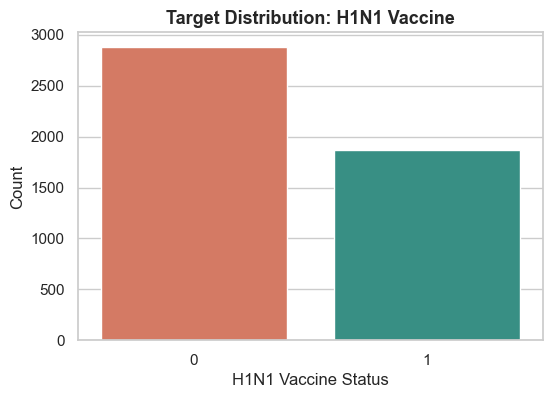

In [42]:
# ============================================================
# CELL 6 — TARGET VARIABLE ANALYSIS
# ============================================================
# Check how the target variable is distributed.
# This helps us understand the class balance.
# ============================================================

target_col = "h1n1_vaccine"

target_summary = pd.DataFrame({
    "Count": train_df[target_col].value_counts(),
    "Percentage": (train_df[target_col].value_counts(normalize=True) * 100).round(2)
})

display(target_summary)

target_summary.to_csv(RESULTS_DIR / "01_target_distribution.csv")

plt.figure(figsize=(6, 4))
sns.countplot(
    data=train_df,
    x=target_col,
    palette=["#E76F51", "#2A9D8F"]
)
plt.title("Target Distribution: H1N1 Vaccine", fontsize=13, weight="bold")
plt.xlabel("H1N1 Vaccine Status")
plt.ylabel("Count")
save_plot("01_target_distribution.png")
plt.show()

,Missing Values,Missing Percentage
employment_sector,2364,49.71
health_insurance,1925,40.48
income_poverty,712,14.97
doctor_recc_h1n1,319,6.71
rent_or_own,315,6.62
employment_status,235,4.94
marital_status,226,4.75
education,224,4.71
chronic_med_condition,161,3.39
child_under_6_months,134,2.82


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\02_missing_values.png


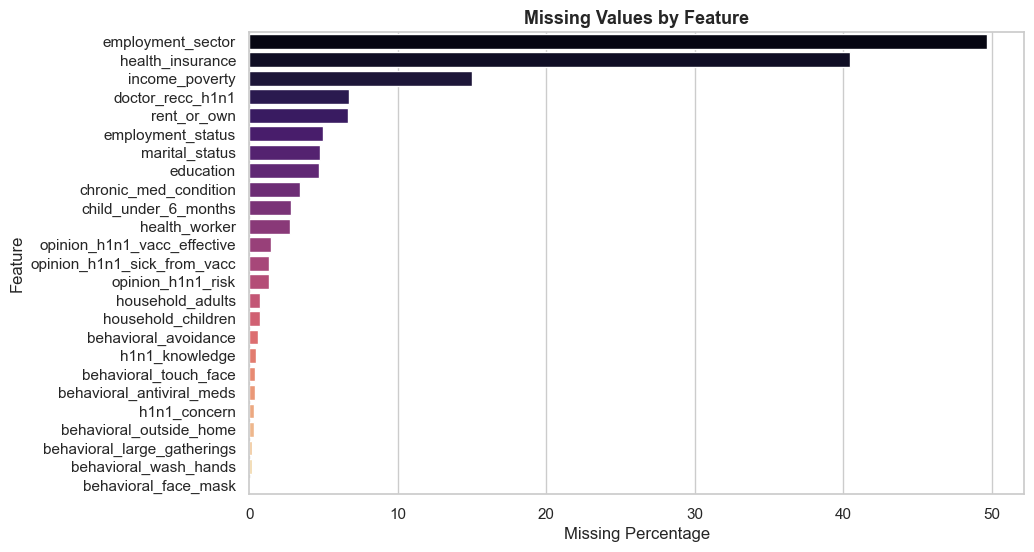

In [43]:
# ============================================================
# CELL 7 — MISSING VALUE ANALYSIS
# ============================================================
# Check missing values before preprocessing.
# This helps decide how the values should be filled later.
# ============================================================

missing_table = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Missing Percentage": (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

missing_table = missing_table[missing_table["Missing Values"] > 0]
missing_table = missing_table.sort_values("Missing Percentage", ascending=False)

display(missing_table)

missing_table.to_csv(RESULTS_DIR / "02_missing_values.csv")

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_table["Missing Percentage"],
    y=missing_table.index,
    palette="magma"
)
plt.title("Missing Values by Feature", fontsize=13, weight="bold")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
save_plot("02_missing_values.png")
plt.show()

In [44]:
# ============================================================
# CELL 8 — IMPORTANT FEATURES FOR EDA
# ============================================================
# These are the main features I focused on for EDA because they are
# closely related to vaccine behaviour and risk perception.
# ============================================================

important_features = [
    "doctor_recc_h1n1",
    "opinion_h1n1_risk",
    "opinion_h1n1_vacc_effective",
    "h1n1_concern",
    "h1n1_knowledge",
    "health_worker",
    "age_group",
    "education"
]

important_features

['doctor_recc_h1n1',
 'opinion_h1n1_risk',
 'opinion_h1n1_vacc_effective',
 'h1n1_concern',
 'h1n1_knowledge',
 'health_worker',
 'age_group',
 'education']

In [45]:
# ============================================================
# CELL 9 — FEATURE VS TARGET FUNCTION
# ============================================================
# This function shows the vaccination rate for each value of a feature.
# It also saves the table and plot.
# ============================================================

def plot_feature_vs_target(data, feature, target):
    rate_table = (
        data.groupby(feature)[target]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    rate_table.columns = [feature, "Vaccination Rate"]

    display(rate_table)

    rate_table.to_csv(
        RESULTS_DIR / f"eda_{feature}_vaccination_rate.csv",
        index=False
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=rate_table,
        x=feature,
        y="Vaccination Rate",
        palette="rocket"
    )
    plt.title(f"Vaccination Rate by {feature}", fontsize=13, weight="bold")
    plt.xlabel(feature)
    plt.ylabel("Vaccination Rate")
    plt.xticks(rotation=45)
    save_plot(f"eda_{feature}_vaccination_rate.png")
    plt.show()

,doctor_recc_h1n1,Vaccination Rate
0,1.0,0.727484
1,0.0,0.279136


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_doctor_recc_h1n1_vaccination_rate.png


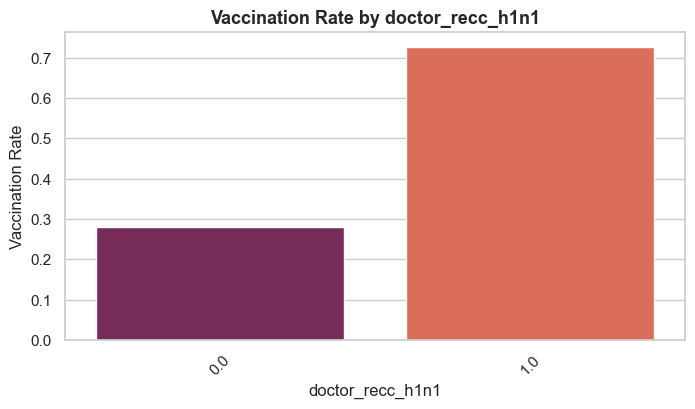

,opinion_h1n1_risk,Vaccination Rate
0,5.0,0.704663
1,4.0,0.610589
2,3.0,0.359551
3,2.0,0.323827
4,1.0,0.198587


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_opinion_h1n1_risk_vaccination_rate.png


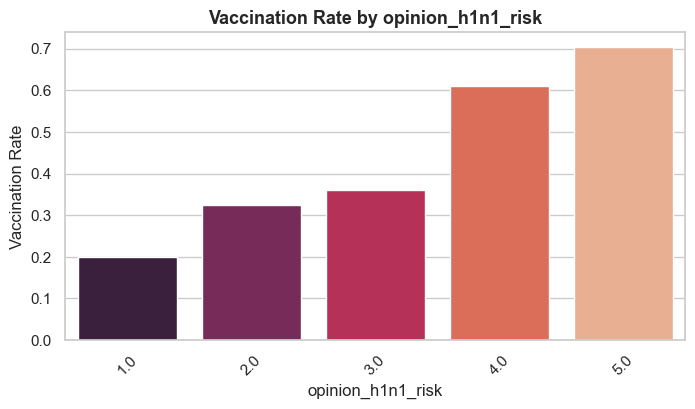

,opinion_h1n1_vacc_effective,Vaccination Rate
0,5.0,0.625416
1,4.0,0.339329
2,3.0,0.222527
3,2.0,0.126923
4,1.0,0.107914


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_opinion_h1n1_vacc_effective_vaccination_rate.png


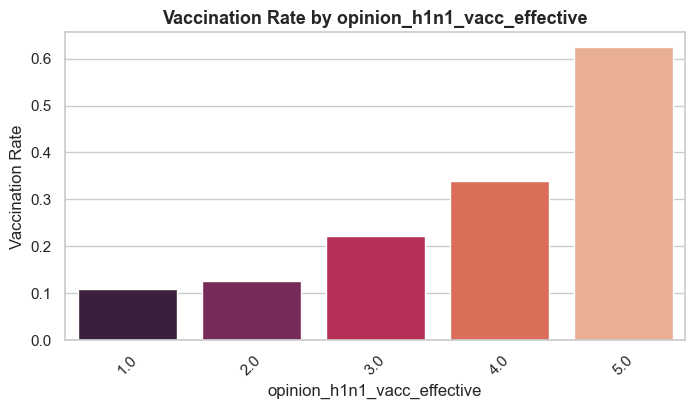

,h1n1_concern,Vaccination Rate
0,3.0,0.509004
1,2.0,0.420707
2,1.0,0.325036
3,0.0,0.295019


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_h1n1_concern_vaccination_rate.png


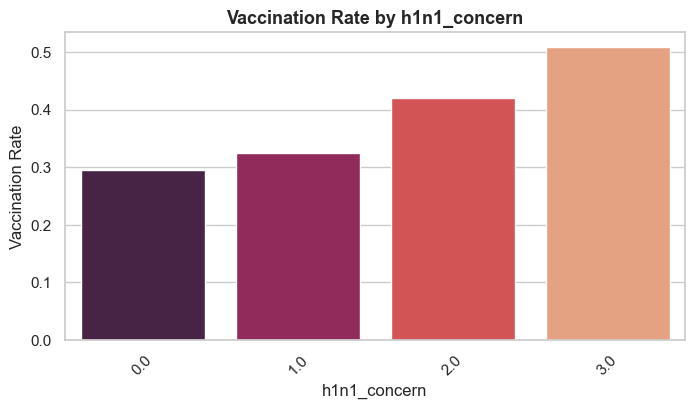

,h1n1_knowledge,Vaccination Rate
0,2.0,0.483415
1,1.0,0.347410
2,0.0,0.272727


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_h1n1_knowledge_vaccination_rate.png


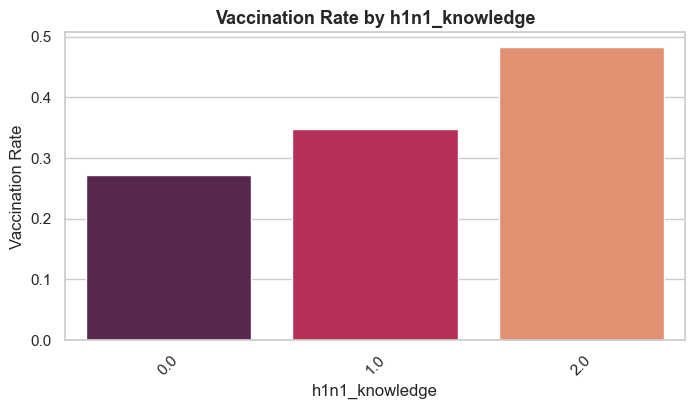

,health_worker,Vaccination Rate
0,1.0,0.643185
1,0.0,0.354733


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_health_worker_vaccination_rate.png


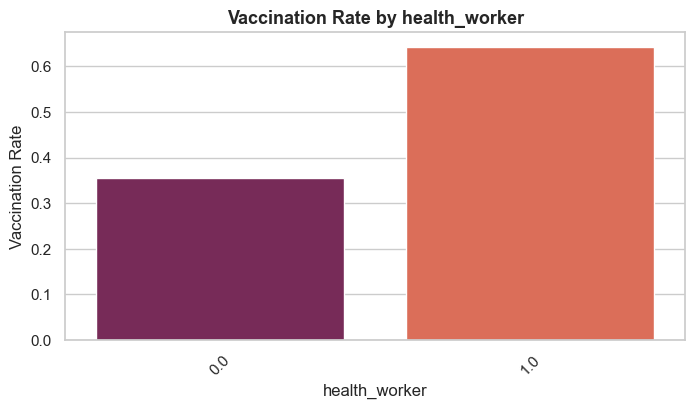

,age_group,Vaccination Rate
0,55 - 64 Years,0.418779
1,65+ Years,0.413878
2,35 - 44 Years,0.396055
3,45 - 54 Years,0.365827
4,18 - 34 Years,0.364653


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_age_group_vaccination_rate.png


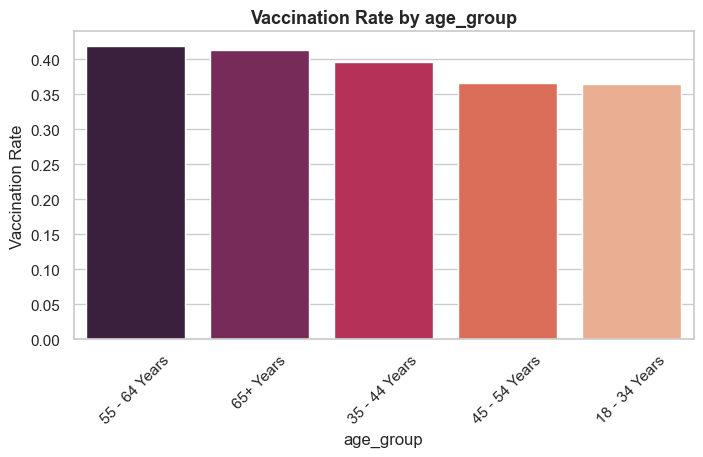

,education,Vaccination Rate
0,College Graduate,0.444564
1,Some College,0.411024
2,< 12 Years,0.324051
3,12 Years,0.323092


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\eda_education_vaccination_rate.png


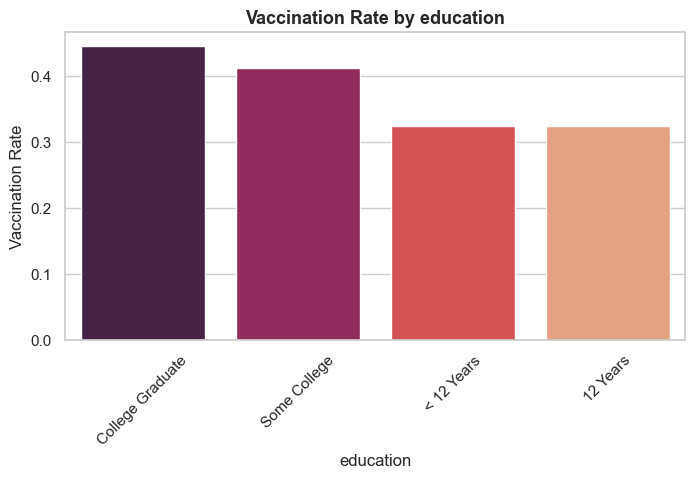

In [46]:
# ============================================================
# CELL 10 — RUN EDA
# ============================================================
# Run the same target comparison for all selected important features.
# This gives presentation-ready EDA outputs.
# ============================================================

for feature in important_features:
    if feature in train_df.columns:
        plot_feature_vs_target(train_df, feature, target_col)
    else:
        print(f"Column not found: {feature}")

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\03_correlation_heatmap.png


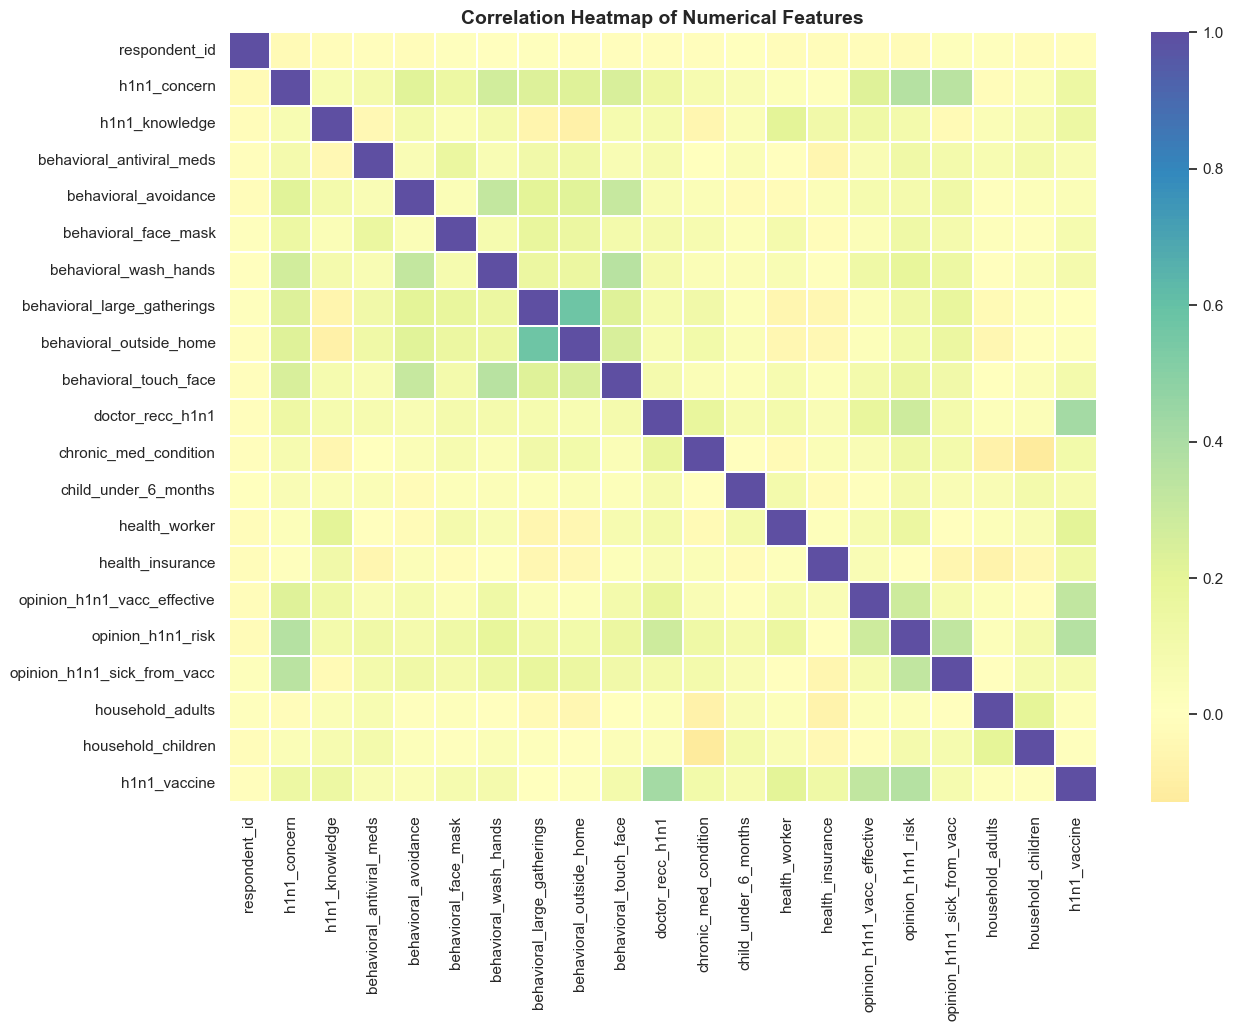

In [47]:
# ============================================================
# CELL 11 — CORRELATION HEATMAP
# ============================================================
# Show correlations between numerical variables.
# This gives a quick view of linear relationships in the data.
# ============================================================

numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns
corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="Spectral",
    center=0,
    linewidths=0.3,
    cbar=True
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, weight="bold")
save_plot("03_correlation_heatmap.png")
plt.show()

In [48]:
# ============================================================
# CELL 12 — PREPARE FEATURES AND TARGET
# ============================================================
# Separate the target column from the input features.
# Keep respondent_id for the final prediction files.
# ============================================================

y = train_df[target_col]
X = train_df.drop(columns=[target_col])

test_respondent_id = (
    test_df["respondent_id"] if "respondent_id" in test_df.columns else range(len(test_df))
)

X_test = test_df.copy()

print("Training features shape:", X.shape)
print("Target shape:", y.shape)
print("Test features shape:", X_test.shape)

Training features shape: (4756, 30)
Target shape: (4756,)
Test features shape: (4749, 30)


In [49]:
# ============================================================
# CELL 13 — MISSING VALUE HANDLING
# ============================================================
# Fill numeric missing values with median and categorical missing
# values with Unknown. The same logic is applied to the test data.
# ============================================================

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

if "respondent_id" in numeric_cols:
    numeric_cols.remove("respondent_id")

for col in numeric_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")

print("Missing values filled.")

Missing values filled.


In [50]:
# ============================================================
# CELL 14 — ONE-HOT ENCODING
# ============================================================
# Convert categorical columns into numeric dummy columns.
# Train and test data are aligned so both have the same features.
# ============================================================

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_encoded, X_test_encoded = X_encoded.align(
    X_test_encoded,
    join="outer",
    axis=1,
    fill_value=0
)

X_encoded = X_encoded.drop(columns=["respondent_id"], errors="ignore")
X_test_encoded = X_test_encoded.drop(columns=["respondent_id"], errors="ignore")

print("Encoded training shape:", X_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (4756, 64)
Encoded test shape: (4749, 64)


In [51]:
# ============================================================
# CELL 15 — CLEAN FEATURE NAMES
# ============================================================
# Some models can fail when column names contain special characters.
# This cell makes the feature names safer to use.
# ============================================================

def clean_column_names(columns):
    cleaned = []

    for col in columns:
        col = str(col)
        col = re.sub(r"[\[\]<>]", "_", col)
        col = re.sub(r"[^A-Za-z0-9_]+", "_", col)
        col = re.sub(r"_+", "_", col)
        col = col.strip("_")
        cleaned.append(col)

    return cleaned


X_encoded.columns = clean_column_names(X_encoded.columns)
X_test_encoded.columns = clean_column_names(X_test_encoded.columns)

print("Column names cleaned.")

Column names cleaned.


In [52]:
# ============================================================
# CELL 16 — TRAIN VALIDATION SPLIT
# ============================================================
# Split the training data into train and validation sets.
# Stratify keeps the target class balance similar.
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (3804, 64)
X_valid: (952, 64)


In [53]:
# ============================================================
# CELL 17 — MODEL EVALUATION FUNCTION
# ============================================================
# Train one model, calculate the main metrics and save a confusion matrix.
# This keeps the model comparison consistent.
# ============================================================

model_results = {}

def evaluate_model(model_name, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_valid)[:, 1]
    else:
        y_proba = model.decision_function(X_valid)

    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)

    model_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

    print(f"\n========== {model_name} ==========")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))

    cm = confusion_matrix(y_valid, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        cbar=False
    )
    plt.title(f"Confusion Matrix - {model_name}", fontsize=13, weight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_plot(f"confusion_matrix_{model_name.replace(' ', '_')}.png")
    plt.show()

    return model


========== Logistic Regression ==========
Accuracy : 0.7447
Precision: 0.661
Recall   : 0.7227
F1 Score : 0.6904
ROC AUC  : 0.8154

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       577
           1       0.66      0.72      0.69       375

    accuracy                           0.74       952
   macro avg       0.73      0.74      0.74       952
weighted avg       0.75      0.74      0.75       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_Logistic_Regression.png


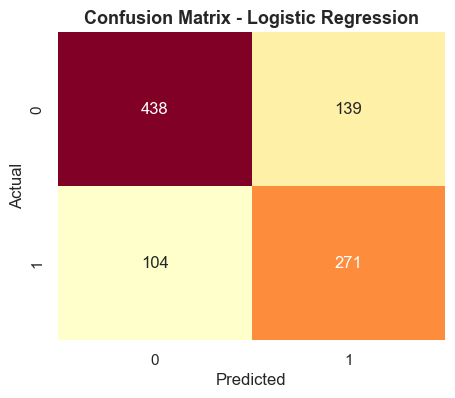

In [55]:
# ============================================================
# CELL 18 — LOGISTIC REGRESSION
# ============================================================
# Simple baseline model.
# This gives a starting point for comparison.
# ============================================================

logistic_model = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_model = evaluate_model("Logistic Regression", logistic_model)


========== Random Forest ==========
Accuracy : 0.7437
Precision: 0.6701
Recall   : 0.688
F1 Score : 0.6789
ROC AUC  : 0.8034

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79       577
           1       0.67      0.69      0.68       375

    accuracy                           0.74       952
   macro avg       0.73      0.73      0.73       952
weighted avg       0.74      0.74      0.74       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_Random_Forest.png


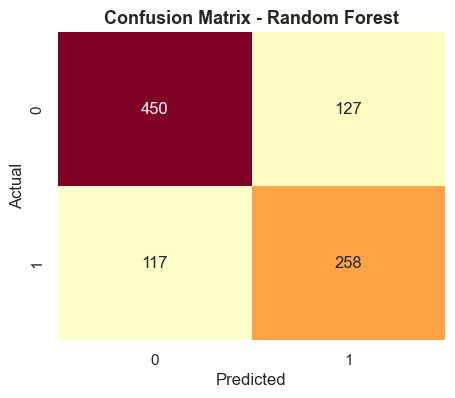

In [56]:
# ============================================================
# CELL 19 — RANDOM FOREST
# ============================================================
# Tree-based model that can capture non-linear patterns.
# Used as a strong comparison model.
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

random_forest_model = evaluate_model("Random Forest", random_forest_model)


========== Gradient Boosting ==========
Accuracy : 0.7616
Precision: 0.7256
Recall   : 0.6347
F1 Score : 0.6771
ROC AUC  : 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       577
           1       0.73      0.63      0.68       375

    accuracy                           0.76       952
   macro avg       0.75      0.74      0.74       952
weighted avg       0.76      0.76      0.76       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_Gradient_Boosting.png


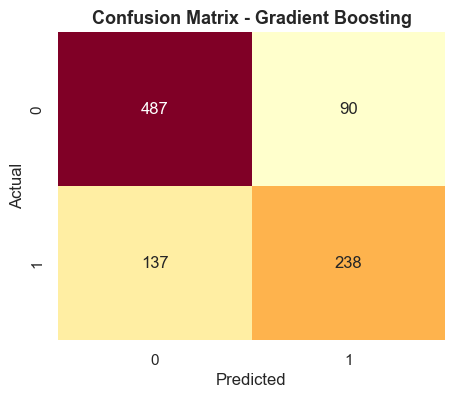

In [57]:
# ============================================================
# CELL 20 — GRADIENT BOOSTING
# ============================================================
# Boosting model included as a stronger ensemble method.
# Useful for tabular classification problems.
# ============================================================

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gradient_boosting_model = evaluate_model("Gradient Boosting", gradient_boosting_model)


========== KNN ==========
Accuracy : 0.7132
Precision: 0.6875
Recall   : 0.4987
F1 Score : 0.5781
ROC AUC  : 0.7483

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       577
           1       0.69      0.50      0.58       375

    accuracy                           0.71       952
   macro avg       0.71      0.68      0.68       952
weighted avg       0.71      0.71      0.70       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_KNN.png


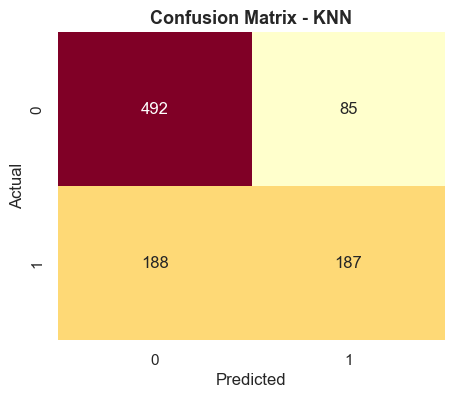

In [58]:
# ============================================================
# CELL 21 — KNN
# ============================================================
# Distance-based model used for comparison.
# It helps show how different model types behave on this data.
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=15
)

knn_model = evaluate_model("KNN", knn_model)


========== SVM ==========
Accuracy : 0.7395
Precision: 0.6632
Recall   : 0.688
F1 Score : 0.6754
ROC AUC  : 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       577
           1       0.66      0.69      0.68       375

    accuracy                           0.74       952
   macro avg       0.73      0.73      0.73       952
weighted avg       0.74      0.74      0.74       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_SVM.png


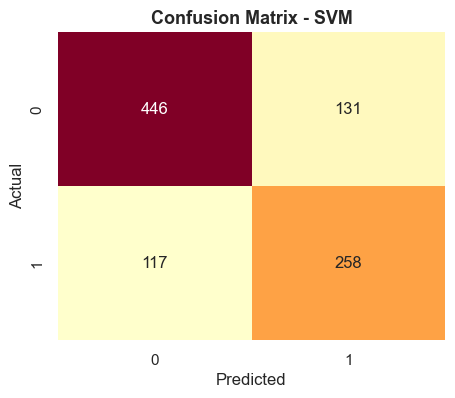

In [59]:
# ============================================================
# CELL 22 — SVM
# ============================================================
# Support Vector Machine used as another comparison model.
# Probability=True is used so ROC-AUC can be calculated.
# ============================================================

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_model = evaluate_model("SVM", svm_model)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8}

========== Tuned Random Forest ==========
Accuracy : 0.7342
Precision: 0.6548
Recall   : 0.688
F1 Score : 0.671
ROC AUC  : 0.8013

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       577
           1       0.65      0.69      0.67       375

    accuracy                           0.73       952
   macro avg       0.72      0.73      0.72       952
weighted avg       0.74      0.73      0.74       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_Tuned_Random_Forest.png


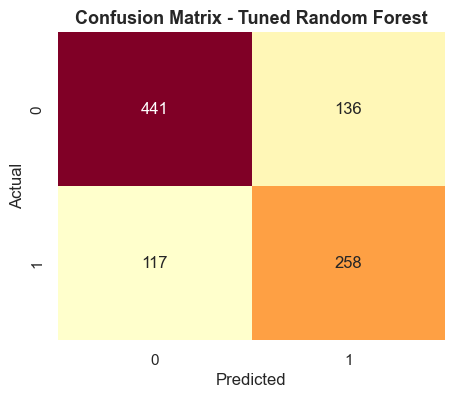

In [60]:
# ============================================================
# CELL 23 — RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================
# Try a few Random Forest settings instead of relying only on one setup.
# The search is kept small because this is a 6-hour hackathon.
# ============================================================

rf_param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

tuned_random_forest_model = rf_search.best_estimator_

tuned_random_forest_model = evaluate_model(
    "Tuned Random Forest",
    tuned_random_forest_model
)

Best Gradient Boosting parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.05}

========== Tuned Gradient Boosting ==========
Accuracy : 0.7605
Precision: 0.7181
Recall   : 0.6453
F1 Score : 0.6798
ROC AUC  : 0.8073

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       577
           1       0.72      0.65      0.68       375

    accuracy                           0.76       952
   macro avg       0.75      0.74      0.74       952
weighted avg       0.76      0.76      0.76       952

Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\confusion_matrix_Tuned_Gradient_Boosting.png


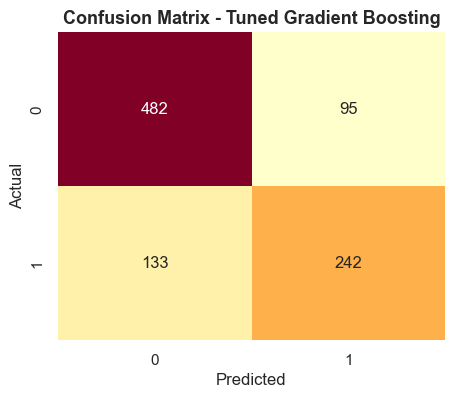

In [61]:
# ============================================================
# CELL 24 — GRADIENT BOOSTING HYPERPARAMETER TUNING
# ============================================================
# Try a small set of Gradient Boosting settings.
# This checks whether tuning improves the model.
# ============================================================

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    param_distributions=gb_param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)

tuned_gradient_boosting_model = gb_search.best_estimator_

tuned_gradient_boosting_model = evaluate_model(
    "Tuned Gradient Boosting",
    tuned_gradient_boosting_model
)

In [62]:
# ============================================================
# CELL 25 — MODEL COMPARISON TABLE
# ============================================================
# Put all model results in one table.
# Models are ranked by ROC-AUC.
# ============================================================

results_df = pd.DataFrame(model_results).T
results_df = results_df.sort_values("ROC AUC", ascending=False)

display(results_df)

results_df.to_csv(RESULTS_DIR / "04_model_comparison_results.csv")

print("Model comparison saved.")

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.744748,0.660976,0.722667,0.690446,0.815413
SVM,0.739496,0.663239,0.688000,0.675393,0.809770
Gradient Boosting,0.761555,0.725610,0.634667,0.677098,0.809319
Tuned Gradient Boosting,0.760504,0.718101,0.645333,0.679775,0.807302
Random Forest,0.743697,0.670130,0.688000,0.678947,0.803374
Tuned Random Forest,0.734244,0.654822,0.688000,0.671001,0.801336
KNN,0.713235,0.687500,0.498667,0.578053,0.748261


Model comparison saved.


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\04_model_comparison_roc_auc.png


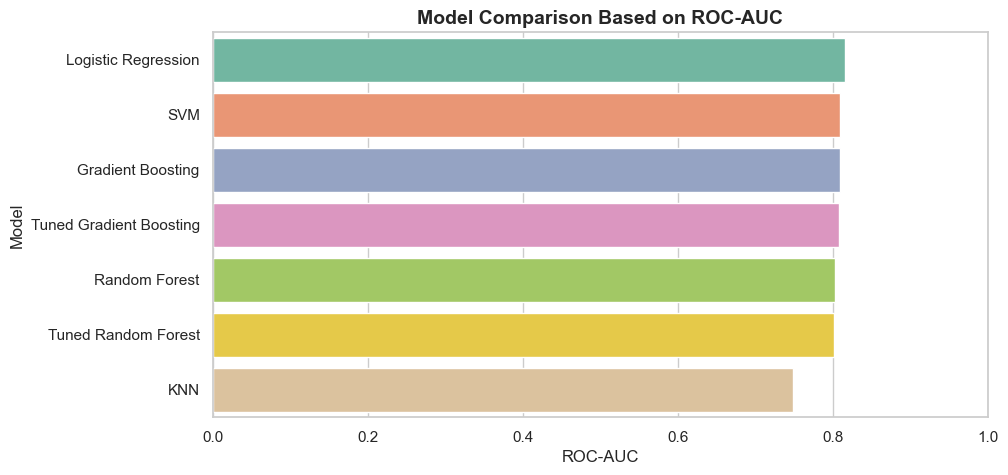

In [63]:
# ============================================================
# CELL 26 — ROC-AUC COMPARISON PLOT
# ============================================================
# Visual comparison of model performance using ROC-AUC.
# This is the main ranking metric used here.
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df.reset_index(),
    x="ROC AUC",
    y="index",
    palette="Set2"
)
plt.title("Model Comparison Based on ROC-AUC", fontsize=14, weight="bold")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
save_plot("04_model_comparison_roc_auc.png")
plt.show()

In [64]:
# ============================================================
# CELL 27 — F1 SCORE RANKING TABLE
# ============================================================
# F1 Score is checked as a second ranking method.
# It balances precision and recall.
# ============================================================

f1_ranking = (
    results_df
    .sort_values("F1 Score", ascending=False)
    .reset_index()
)

f1_ranking.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

f1_ranking.insert(0, "Rank", range(1, len(f1_ranking) + 1))

display(f1_ranking)

f1_ranking.to_csv(
    RESULTS_DIR / "04A_model_ranking_by_f1_score.csv",
    index=False
)

print("F1 ranking saved.")

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,Logistic Regression,0.744748,0.660976,0.722667,0.690446,0.815413
1,2,Tuned Gradient Boosting,0.760504,0.718101,0.645333,0.679775,0.807302
2,3,Random Forest,0.743697,0.670130,0.688000,0.678947,0.803374
3,4,Gradient Boosting,0.761555,0.725610,0.634667,0.677098,0.809319
4,5,SVM,0.739496,0.663239,0.688000,0.675393,0.809770
5,6,Tuned Random Forest,0.734244,0.654822,0.688000,0.671001,0.801336
6,7,KNN,0.713235,0.687500,0.498667,0.578053,0.748261


F1 ranking saved.


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\04A_model_ranking_f1_score.png


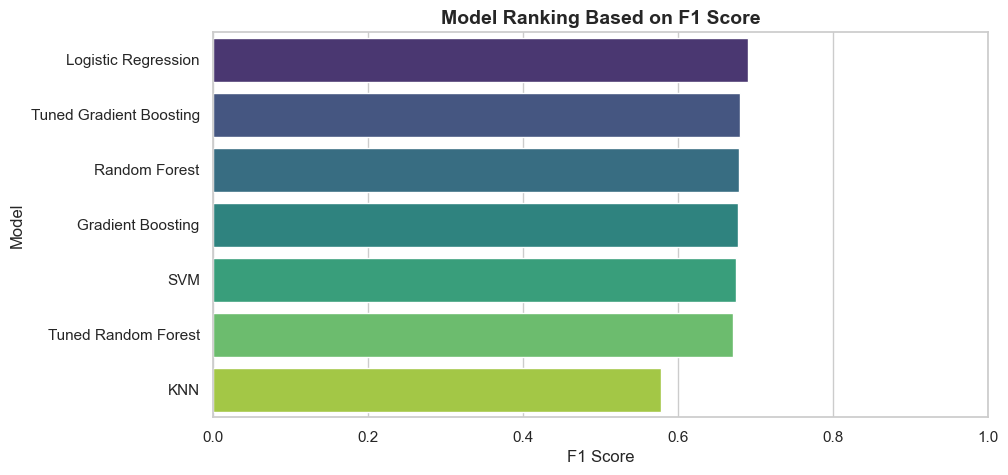

In [65]:
# ============================================================
# CELL 28 — F1 SCORE RANKING PLOT
# ============================================================
# Plot the models based on F1 Score.
# This gives another useful view for the presentation.
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=f1_ranking,
    x="F1 Score",
    y="Model",
    palette="viridis"
)
plt.title("Model Ranking Based on F1 Score", fontsize=14, weight="bold")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
save_plot("04A_model_ranking_f1_score.png")
plt.show()

,Feature,Importance
9,doctor_recc_h1n1,0.402274
14,opinion_h1n1_vacc_effective,0.169775
15,opinion_h1n1_risk,0.164568
12,health_worker,0.037299
16,opinion_h1n1_sick_from_vacc,0.019762
1,h1n1_knowledge,0.017022
51,employment_sector_healthcare,0.013946
60,employment_sector_technology,0.012844
17,household_adults,0.012667
22,age_group_65_Years,0.011305


Saved plot: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Outputs\Plots\05_top_20_feature_importance.png


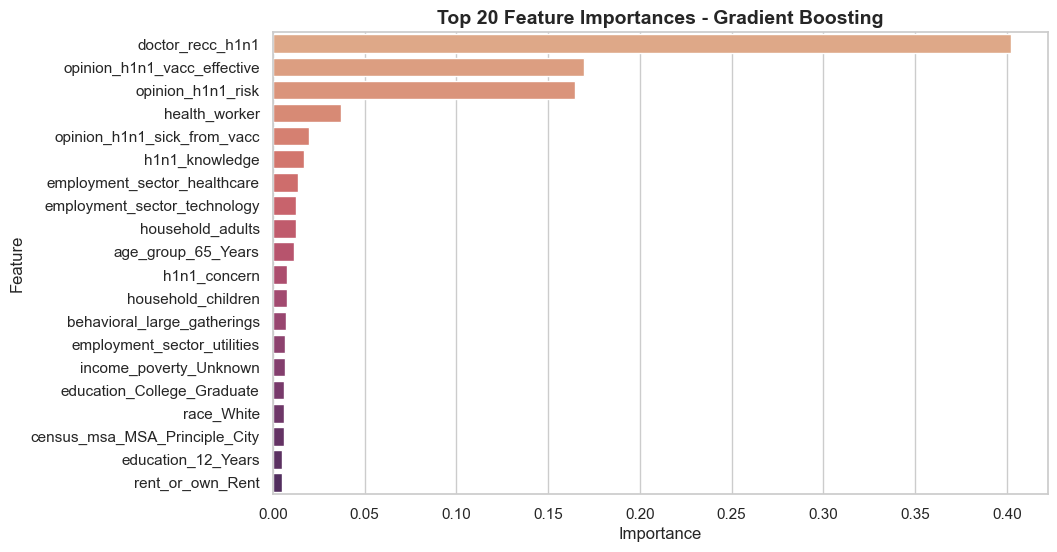

In [66]:
# ============================================================
# CELL 29 — FEATURE IMPORTANCE
# ============================================================
# Use the best tree-based model to show important features.
# This gives a simple explainability section.
# ============================================================

tree_models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
    "Tuned Random Forest": tuned_random_forest_model,
    "Tuned Gradient Boosting": tuned_gradient_boosting_model
}

best_tree_name = max(
    tree_models,
    key=lambda name: model_results[name]["ROC AUC"]
)

best_tree_model = tree_models[best_tree_name]

importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": best_tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

top_20_features = importance_df.head(20)

display(top_20_features)

top_20_features.to_csv(
    RESULTS_DIR / "05_top_20_feature_importance.csv",
    index=False
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature",
    palette="flare"
)
plt.title(f"Top 20 Feature Importances - {best_tree_name}", fontsize=14, weight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
save_plot("05_top_20_feature_importance.png")
plt.show()

In [67]:
# ============================================================
# CELL 30 — GENERATE PREDICTION FILES
# ============================================================
# Save the top 5 prediction files based on validation ROC-AUC.
# Probabilities are used for the final submission.
# ============================================================

model_dict = {
    "LogisticRegression": logistic_model,
    "RandomForest": random_forest_model,
    "GradientBoosting": gradient_boosting_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "TunedRandomForest": tuned_random_forest_model,
    "TunedGradientBoosting": tuned_gradient_boosting_model
}

top_5_models = results_df.head(5).index.tolist()

for rank, model_name in enumerate(top_5_models, start=1):

    safe_model_name = model_name.replace(" ", "")

    model = model_dict[safe_model_name]

    if hasattr(model, "predict_proba"):
        prediction_probabilities = model.predict_proba(X_test_encoded)[:, 1]
    else:
        prediction_probabilities = model.decision_function(X_test_encoded)

    submission = pd.DataFrame({
        "respondent_id": test_respondent_id,
        "h1n1_vaccine": prediction_probabilities
    })

    output_path = RESULTS_DIR / f"{rank}_{safe_model_name}.csv"
    submission.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")

Saved: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv\1_LogisticRegression.csv
Saved: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv\2_SVM.csv
Saved: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv\3_GradientBoosting.csv
Saved: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv\4_TunedGradientBoosting.csv
Saved: C:\Users\girid\OneDrive\Desktop\Research Methods Hackathon\Hackathon_10_7_Dataset_B\Results csv\5_RandomForest.csv


In [68]:
# ============================================================
# CELL 31 — PROJECT SUMMARY
# ============================================================
# Save a short summary of the workflow.
# This is useful for the README, slides and final explanation.
# ============================================================

summary_notes = pd.DataFrame({
    "Section": [
        "Problem Type",
        "Target Variable",
        "Validation Strategy",
        "Preprocessing",
        "Models Used",
        "Hyperparameter Tuning",
        "Main Metrics",
        "Explainability"
    ],
    "Description": [
        "Binary Classification",
        "h1n1_vaccine",
        "80/20 stratified train-validation split",
        "Median imputation, Unknown category handling, and one-hot encoding",
        "Logistic Regression, Random Forest, Gradient Boosting, KNN, SVM",
        "RandomizedSearchCV used for Random Forest and Gradient Boosting",
        "ROC-AUC, F1 Score, Precision, Recall, Accuracy",
        "Feature importance from the best tree-based model"
    ]
})

display(summary_notes)

summary_notes.to_csv(
    RESULTS_DIR / "06_project_summary_notes.csv",
    index=False
)

print("Final project summary saved.")

,Section,Description
0,Problem Type,Binary Classification
1,Target Variable,h1n1_vaccine
2,Validation Strategy,80/20 stratified train-validation split
3,Preprocessing,"Median imputation, Unknown category handling, ..."
4,Models Used,"Logistic Regression, Random Forest, Gradient B..."
5,Hyperparameter Tuning,RandomizedSearchCV used for Random Forest and ...
6,Main Metrics,"ROC-AUC, F1 Score, Precision, Recall, Accuracy"
7,Explainability,Feature importance from the best tree-based model


Final project summary saved.
